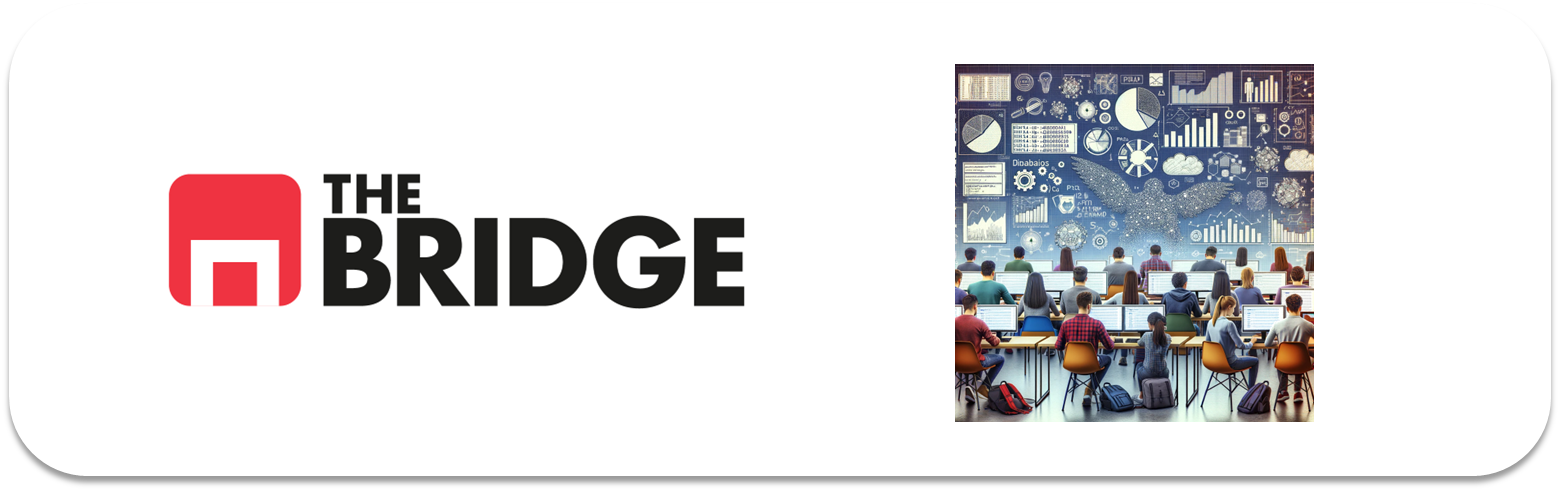

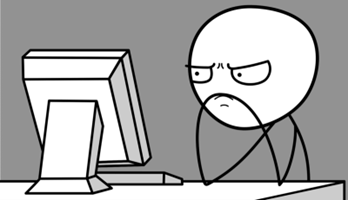

Para ejercitarte y afianzar lo aprendido sobre **Regularización**, completa los siguientes ejercicios. Recuerda que necesitarás datos que están en el directorio data que acompaña al notebook (búscalo en el repositorio de ejercicios)
  
La solución a los mismos las tienes ya, intenta no mirarlos de primeras pero no dejes de hacerlo cuando hayas terminado por si te pudieran aportar.

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook

In [1]:
import numpy as np
import pandas as pd
from sklearn import linear_model, metrics, model_selection
from sklearn.linear_model import ElasticNet
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge
import seaborn as sns

En estos ejercicios vamos a repasar la regularización sobre regresión lineal obteniendo primero un modelo de regresión lineal para predecir el precio de un coche y luego los equivalentes con penalizaciones L2 (Ridge), L1 (Lasso) y con la combinación de ambas (ElasticNet)

### Ejercicio 1

Carga el dataset de partida ("./data/CarPrice_Assignment.csv") en el que tenemos diferentes modelos de coches con sus características y el precio de estos. Échale un vistazo

In [28]:
df = pd.read_csv("./data/CarPrice_Assignment.csv")

In [3]:
df.head()

,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,1,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
1,2,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
2,3,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0
3,4,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0
4,5,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   car_ID            205 non-null    int64  
 1   symboling         205 non-null    int64  
 2   CarName           205 non-null    object 
 3   fueltype          205 non-null    object 
 4   aspiration        205 non-null    object 
 5   doornumber        205 non-null    object 
 6   carbody           205 non-null    object 
 7   drivewheel        205 non-null    object 
 8   enginelocation    205 non-null    object 
 9   wheelbase         205 non-null    float64
 10  carlength         205 non-null    float64
 11  carwidth          205 non-null    float64
 12  carheight         205 non-null    float64
 13  curbweight        205 non-null    int64  
 14  enginetype        205 non-null    object 
 15  cylindernumber    205 non-null    object 
 16  enginesize        205 non-null    int64  
 1

In [11]:
df.describe()

,car_ID,symboling,wheelbase,carlength,carwidth,carheight,curbweight,enginesize,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
count,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000
mean,103.000000,0.834146,98.756585,174.049268,65.907805,53.724878,2555.565854,126.907317,3.329756,3.255415,10.142537,104.117073,5125.121951,25.219512,30.751220,13276.710571
std,59.322565,1.245307,6.021776,12.337289,2.145204,2.443522,520.680204,41.642693,0.270844,0.313597,3.972040,39.544167,476.985643,6.542142,6.886443,7988.852332
min,1.000000,-2.000000,86.600000,141.100000,60.300000,47.800000,1488.000000,61.000000,2.540000,2.070000,7.000000,48.000000,4150.000000,13.000000,16.000000,5118.000000
25%,52.000000,0.000000,94.500000,166.300000,64.100000,52.000000,2145.000000,97.000000,3.150000,3.110000,8.600000,70.000000,4800.000000,19.000000,25.000000,7788.000000
50%,103.000000,1.000000,97.000000,173.200000,65.500000,54.100000,2414.000000,120.000000,3.310000,3.290000,9.000000,95.000000,5200.000000,24.000000,30.000000,10295.000000
75%,154.000000,2.000000,102.400000,183.100000,66.900000,55.500000,2935.000000,141.000000,3.580000,3.410000,9.400000,116.000000,5500.000000,30.000000,34.000000,16503.000000
max,205.000000,3.000000,120.900000,208.100000,72.300000,59.800000,4066.000000,326.000000,3.940000,4.170000,23.000000,288.000000,6600.000000,49.000000,54.000000,45400.000000


### Ejercicio 2

Identifica la variable target y asignala a una variable de nombre `target`, luego elimina de forma permanente el campo "car_ID"

In [29]:
target = df["price"]
df.drop("car_ID", axis = 1, inplace = True)

### Ejercicio 3

Haz un split del dataset en train y test al 80/20 empleando la función de sklearn que ya conoces

In [30]:
from sklearn.model_selection import train_test_split

train_set, test_set = train_test_split(df, test_size=0.2, random_state=42)

### Ejercicio 4

Aunque vamos a emplear todas las variabes numéricas del dataset como predictores o features, obten la correlación de todas ellas con el target y escoge los que creas que son tus tres mejores predictores. Crea una lista con los nombres de las variables numéricas y llámalo `features_num`

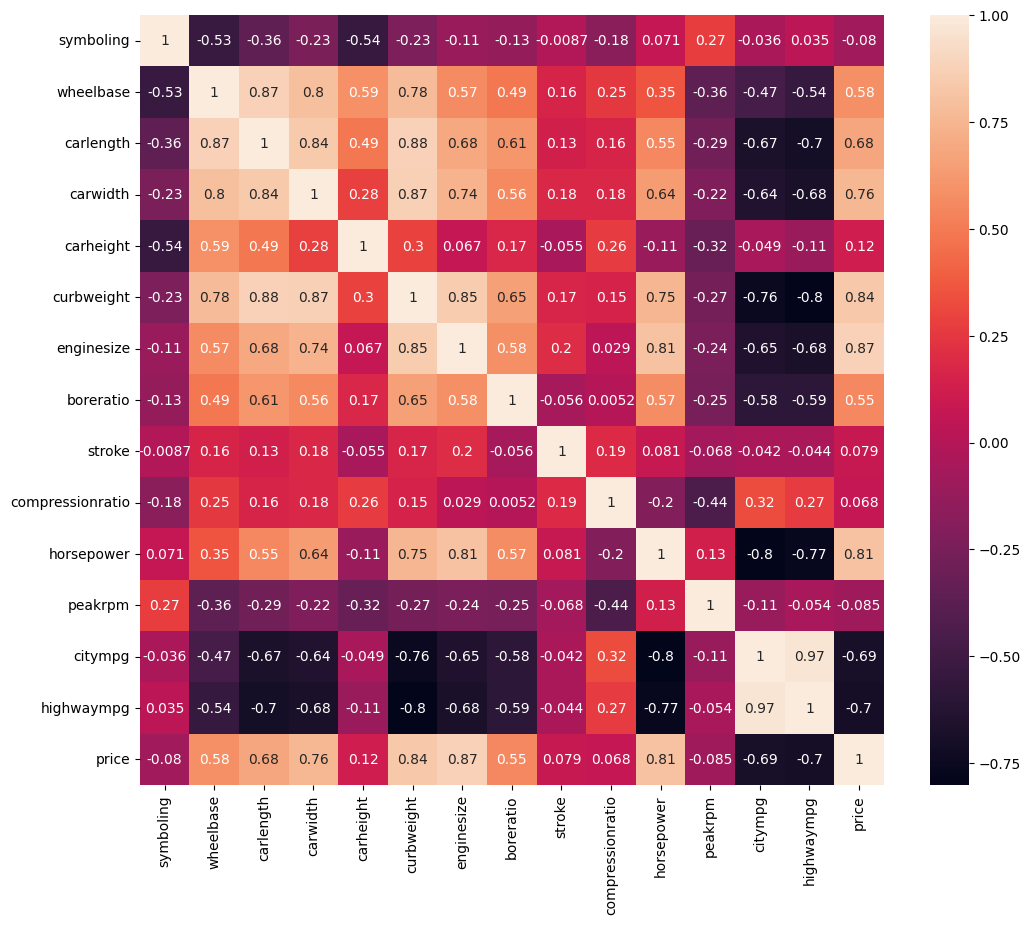

In [31]:
lst = df.describe().columns
plt.figure(figsize=(12, 10))
sns.heatmap(df[lst].corr(numeric_only = True),annot=True);
plt.show();
features_num = ["carwidth", "curbweight", "enginesize"]

### Ejercicio 5

Completa el siguiente código que tiene como objetivo generar un modelo de regresión lineal utilizando todos los valores de las variables (salvo la target):

In [38]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

# Separación x e y
X_train = train_set.drop(columns = ["price"])
y_train = train_set["price"]

X_test = test_set.drop(columns = ["price"])
y_test = test_set["price"]

scaler = StandardScaler()

X_train = pd.DataFrame(scaler.fit_transform(X_train[features_num]), columns= features_num)
X_test = pd.DataFrame(scaler.transform(X_test[features_num]), columns= features_num)

lin_reg = LinearRegression()
lin_reg.fit(X_train,y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


### Ejercicio 6

Obten el MAE,RMSE y $R^2$ para las predicciones sobre train (X_train) y para las predicciones sobre test (X_test). ¿Podemos esperar una buena generalización?

In [40]:
y_train_pred = lin_reg.predict(X_train)
y_test_pred = lin_reg.predict(X_test)


print('MAE train', metrics.mean_absolute_error(y_train, y_train_pred))
print('RMSE train', np.sqrt(metrics.mean_squared_error(y_train, y_train_pred)))
print('R2 train', lin_reg.score(X_train,y_train))


print('MAE test', metrics.mean_absolute_error(y_test, y_test_pred))
print('RMSE test', np.sqrt(metrics.mean_squared_error(y_test, y_test_pred)))
print('R2 test', lin_reg.score(X_test,y_test))

MAE train 2471.6281268385333
RMSE train 3517.6930478680124
R2 train 0.7925115174963961
MAE test 2539.8737138521055
RMSE test 3755.3263405865396
R2 test 0.8213610636098595


Sí. Las métricas en train y test son muy similares, lo que indica que el modelo no está sobreajustado y generaliza de forma razonable, aunque los errores absolutos muestran margen claro de mejora.

### Ejercicio 7
 
Vamos a regularizar, crea un regresor Ridge con alpha inicial a 10 y entrenalo con el X_train. Obten MAE, RMSE y $R^2$ considerando las predicciones sobre el mismo X_train

In [50]:
from sklearn.linear_model import Ridge

ridgeR = Ridge(alpha = 10) # alpha es lambda 
ridgeR.fit(X_train, y_train)

print('MAE train Sin regularización', metrics.mean_absolute_error(y_train, y_train_pred))
print('RMSE train Sin regularización', np.sqrt(metrics.mean_squared_error(y_train, y_train_pred)))
print('R2 train Sin regularización', lin_reg.score(X_train,y_train))

print('MAE test Sin regularización', metrics.mean_absolute_error(y_test, y_test_pred))
print('RMSE test Sin regularización', np.sqrt(metrics.mean_squared_error(y_test, y_test_pred)))
print('R2 test Sin regularización', lin_reg.score(X_test,y_test))


print("\n------------------------------------------------------------\n")
y_train_pred_ridge = ridgeR.predict(X_train)
y_test_pred_ridge = ridgeR.predict(X_test)

print('MAE train', metrics.mean_absolute_error(y_train, y_train_pred_ridge))
print('RMSE train', np.sqrt(metrics.mean_squared_error(y_train, y_train_pred_ridge)))
print('R2 train', ridgeR.score(X_train,y_train))

print('MAE test', metrics.mean_absolute_error(y_test, y_test_pred_ridge))
print('RMSE test', np.sqrt(metrics.mean_squared_error(y_test, y_test_pred_ridge)))
print('R2 test', ridgeR.score(X_test,y_test))


MAE train Sin regularización 2471.6281268385333
RMSE train Sin regularización 3517.6930478680124
R2 train Sin regularización 0.7925115174963961
MAE test Sin regularización 2539.8737138521055
RMSE test Sin regularización 3755.3263405865396
R2 test Sin regularización 0.8213610636098595

------------------------------------------------------------

MAE train 2458.7751600602605
RMSE train 3531.0143404115993
R2 train 0.790937049050036
MAE test 2540.220698728971
RMSE test 3782.3311176183897
R2 test 0.8187826193308231


### Ejercicio 8

Evalúalo contra el X_test y obten MAE,RMSE y $R^2$. ¿Es mejor generalizado que la regresión lineal sin regularizar?

no, empeora ligeramente.

### Ejercicio 9
 
Ahora crea un regresor Lasso con alpha inicial a 125 y entrenalo con el X_train. Obten MAE, RMSE y $R^2$ considerando las predicciones sobre el mismo X_train.

In [55]:
from sklearn.linear_model import Lasso

lassoR = Lasso(alpha=125)
lassoR.fit(X_train, y_train)


y_train_pred_lasso = lassoR.predict(X_train)

print('MAE train', metrics.mean_absolute_error(y_train, y_train_pred_lasso))
print('RMSE train', np.sqrt(metrics.mean_squared_error(y_train, y_train_pred_lasso)))
print('R2 train', lassoR.score(X_train,y_train))


MAE train 2472.712699410152
RMSE train 3520.307871824286
R2 train 0.7922029359948575


### Ejercicio 10

Evalúalo contra el X_test y obten MAE,RMSE y $R^2$. ¿Es mejor generalizado que los otros dos modelos?

In [ ]:
y_test_pred_lasso = lassoR.predict(X_test)

print('MAE test', metrics.mean_absolute_error(y_test, y_test_pred_lasso))
print('RMSE test', np.sqrt(metrics.mean_squared_error(y_test, y_test_pred_lasso)))
print('R2 test', lassoR.score(X_test,y_test))

MAE test 2520.348687148699
RMSE test 3762.172704271397
R2 test 0.8207091138879151


### Ejercicio 11

Repite los ejercicios 9 y 10 con un regresos ElasticNet con alpha 0.2 y l1_ratio a 0.7. ¿Es mejor generalizando que el resto?

In [59]:
from sklearn.linear_model import ElasticNet

elastic_net = ElasticNet(alpha = 0.2, l1_ratio = 0.7)
elastic_net.fit(X_train, y_train)

y_train_pred_elasticNet = elastic_net.predict(X_train)
y_test_pred_elasticNet = elastic_net.predict(X_test)

print('MAE train', metrics.mean_absolute_error(y_train, y_train_pred_elasticNet))
print('RMSE train', np.sqrt(metrics.mean_squared_error(y_train, y_train_pred_elasticNet)))
print('R2 train', elastic_net.score(X_train,y_train))

print('MAE test', metrics.mean_absolute_error(y_test, y_test_pred_elasticNet))
print('RMSE test', np.sqrt(metrics.mean_squared_error(y_test, y_test_pred_elasticNet)))
print('R2 test', elastic_net.score(X_test,y_test))

MAE train 2458.8937839645137
RMSE train 3530.6727735881454
R2 train 0.7909774938103004
MAE test 2540.0044884849453
RMSE test 3781.7593502732425
R2 test 0.8188374037195214


### Ejercicio 12

¿Qué podrías hacer para mejorar los regresores regularizados?

Jugar con los hiperparámetros como alpha y l1_ratio para encontrar un mejor trade-off entre bias y variance.

### EXTRA:

Utiliza la función siguiente para pintar la importancia de los coeficientes en cada uno de los cuatro modelos y observa el efecto de las penalizaciones de cada una de las regularizaciones:

In [60]:
def show_coefs(model, figsize=(10, 5)):
    df_coef = pd.DataFrame(model.coef_, index=model.feature_names_in_, columns=["coefs"])

    fig, ax = plt.subplots(1, 2, figsize=figsize)
    df_coef.plot(kind="barh", ax=ax[0], legend=False)
    df_coef.abs().sort_values(by="coefs").plot(kind="barh", ax=ax[1], legend=False)
    fig.suptitle("Model Coefficients")

    fig.tight_layout()

    return df_coef

,coefs
carwidth,1340.434558
curbweight,1419.471493
enginesize,4561.886833


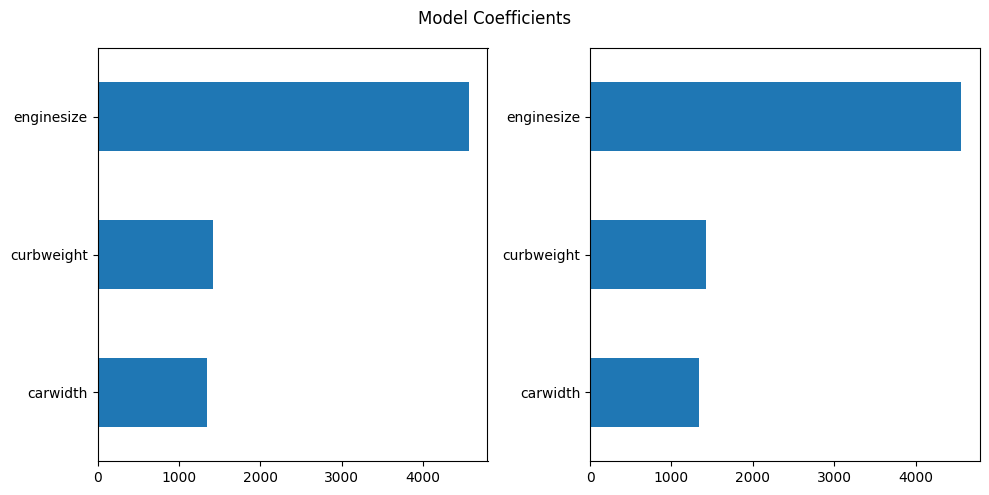

In [61]:
show_coefs(lin_reg)

,coefs
carwidth,1358.255301
curbweight,1736.038596
enginesize,4038.498421


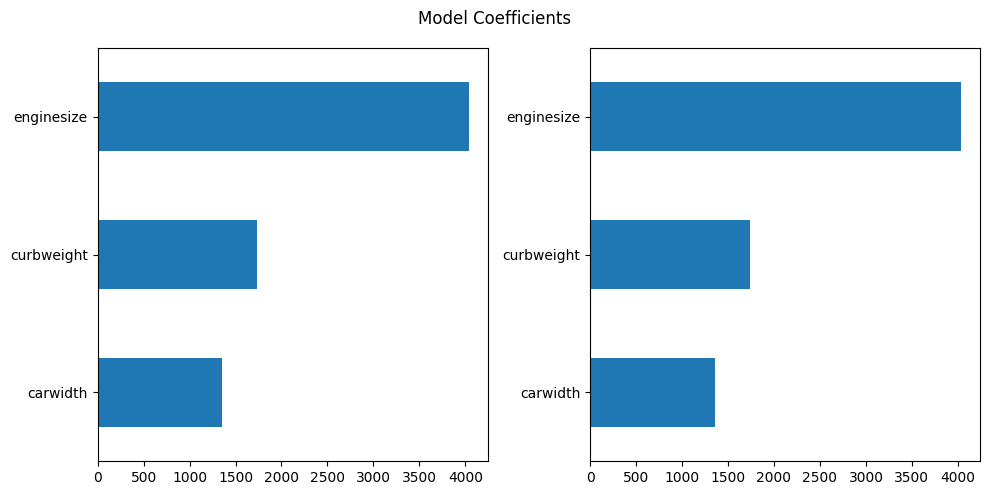

In [62]:
show_coefs(ridgeR)

,coefs
carwidth,1270.851371
curbweight,1410.840808
enginesize,4493.037697


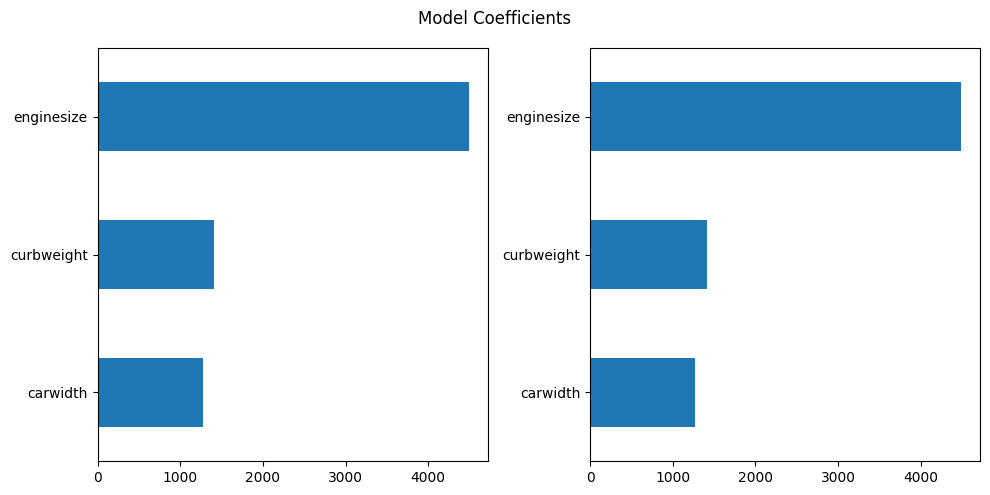

In [63]:
show_coefs(lassoR)

,coefs
carwidth,1357.503570
curbweight,1732.974399
enginesize,4044.998342


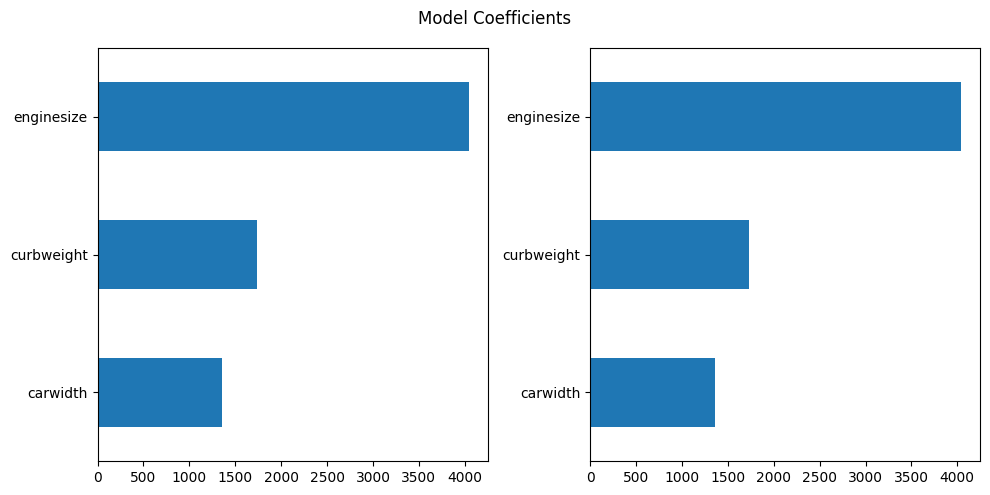

In [65]:
show_coefs(elastic_net)